# Extract ROI by convolution

In [45]:
import h5py
import numpy as np
import hdf5plugin
from matplotlib import pyplot as plt
import time

from scipy import signal
from scipy.ndimage import uniform_filter
import sys
sys.path.append("../src/utils/")
sys.path.append("../src/utils/IEBCS")
import eventIO
import event_representations
import tqdm

In [162]:
# load events
# buf = eventIO.load_hdf5("/home/lkolmar/Documents/metavision/recordings/new_real_dataset/raw_data/program1/spin2_sidespin0_0.hdf5")
buf = eventIO.load_hdf5("/home/lkolmar/Documents/metavision/recordings/new_real_dataset/raw_data/program5/spin-4_sidespin0_6.hdf5")
x = buf.get_x()
y = buf.get_y()
t = buf.get_ts()
p = buf.get_p()
print(np.min(t), np.max(t))
print(np.min(x), np.max(x))
print(np.min(y), np.max(y))

t = t - np.min(t)
print(np.min(t), np.max(t))
buf.ts = t

18113000 18283998
0 1279
213 587
0 170998


## Generate matrices

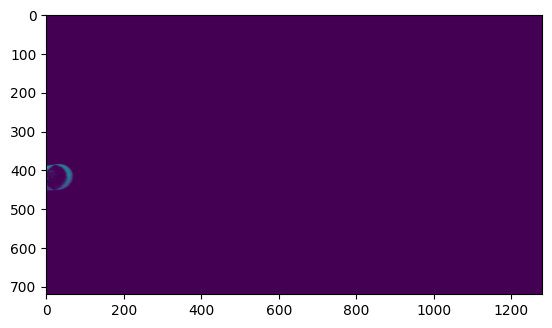

In [163]:
width, height = 1280, 720
num_bins = 100
images = np.zeros((num_bins, height, width), dtype=np.float32)
dt = (np.max(t) - np.min(t)) / num_bins
# Compute bin indices for each event
bin_indices = np.floor((t - np.min(t)) / dt).astype(int)
bin_indices = np.clip(bin_indices, 0, num_bins - 1)

# Use numpy's advanced indexing to accumulate counts
np.add.at(images, (bin_indices, y, x), 1)

plt.imshow(images[0])
plt.show()

15.0 0.0


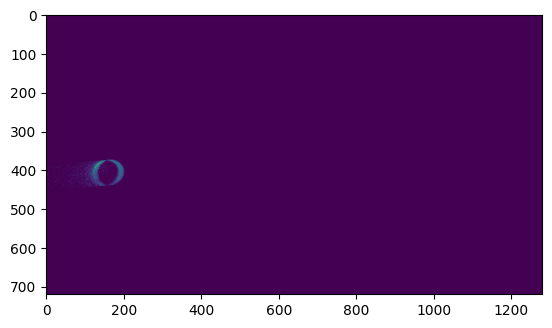

In [164]:
print(np.max(images), np.min(images))
plt.imshow(images[10])
plt.show()

In [165]:
def center_of_ones(matrix):
    ys, xs = np.nonzero(matrix)
    if len(xs) == 0:
        return None
    
    x_center = xs.mean()
    y_center = ys.mean()
    return x_center, y_center

In [166]:
def get_center(matrix, kernel, p):
    convolved = signal.convolve2d(matrix, kernel, 'same', 'fill', 0)
    convolved2 = convolved>np.max(convolved)*p
    return center_of_ones(convolved2)

In [167]:
def find_centers(images, radius, p=0.8):
    r = radius
    kernel = np.zeros((int(2*r)+1, int(2*r)+1))
    for y in range(int(2*r)):
        y1 = y - r
        x1 = r + int(np.sqrt(r**2 - y1**2))
        x2 = r - int(np.sqrt(r**2 - y1**2))
        kernel[x1][y] = 1
        kernel[x2][y] = 1

    centers = [get_center(k, kernel, p) for k in tqdm.tqdm(images)]
    return centers

In [168]:
def process_sequence(buffer, n_centers, n_coordinates, n_bins=100):
    # make sure ts start at 0
    x = buffer.get_x()
    y = buffer.get_y()
    t = buffer.get_ts()
    t = t - np.min(t)

    # create images
    width, height = 1280, 720 # always the same for our recordings
    images = np.zeros((n_bins, height, width), dtype=np.float32)
    dt = (np.max(t) - np.min(t)) / n_bins
    bin_indices = np.floor((t - np.min(t)) / dt).astype(int)
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
    np.add.at(images, (bin_indices, y, x), 1)

    # select n_centers images
    step = n_bins // n_centers
    print(f"Selecting every {step} image to get {n_centers} centers.")
    selected_indices = np.round(np.linspace(0, n_bins - 1, n_centers)).astype(int)
    selected_images = images[selected_indices]

    # extract centers
    centers = find_centers(selected_images, radius=30)
    return centers, selected_indices

## testing

In [169]:
bins = 600
n_images = 600
centers = 20
width, height = 1280, 720 # always the same for our recordings
images = np.zeros((n_images, height, width), dtype=np.float32)
dt = (np.max(t) - np.min(t)) / n_images
bin_indices = np.floor((t - np.min(t)) / dt).astype(int)
bin_indices = np.clip(bin_indices, 0, n_images - 1)
np.add.at(images, (bin_indices, y, x), 1)

In [170]:
coords, idxs = process_sequence(buf, n_centers=centers, n_coordinates=600, n_bins=bins)

Selecting every 30 image to get 20 centers.


100%|██████████| 20/20 [01:19<00:00,  3.98s/it]


In [151]:
print("Indexes: ")
for i in idxs:
    print(i, end=", ")

Indexes: 
0, 32, 63, 95, 126, 158, 189, 221, 252, 284, 315, 347, 378, 410, 441, 473, 504, 536, 567, 599, 

In [152]:
def interpolate_positions(known_positions, n_coordinates, known_indices=None):
    known_positions = np.asarray(known_positions, dtype=np.float32)
    if known_indices is None:
        idx = np.round(np.linspace(0, n_coordinates - 1, len(known_positions))).astype(int)
    else:
        idx = np.asarray(known_indices, dtype=np.int32)

    order = np.argsort(idx)
    idx = idx[order]
    known_positions = known_positions[order]

    uniq_idx, inv = np.unique(idx, return_inverse=True)
    if len(uniq_idx) != len(idx):
        agg = np.zeros((len(uniq_idx), 2), dtype=np.float32)
        counts = np.bincount(inv)
        agg[:, 0] = np.bincount(inv, weights=known_positions[:, 0]) / counts
        agg[:, 1] = np.bincount(inv, weights=known_positions[:, 1]) / counts
        idx = uniq_idx
        known_positions = agg

    frames = np.arange(n_coordinates)
    out = np.empty((n_coordinates, 2), dtype=np.float32)
    out[:, 0] = np.interp(frames, idx, known_positions[:, 0])
    out[:, 1] = np.interp(frames, idx, known_positions[:, 1])
    return out

In [171]:
full_positions = interpolate_positions(coords, n_images, known_indices=idxs)
def find_coord(idx):
    return full_positions[idx]

In [176]:
with open("/home/lkolmar/Documents/metavision/recordings/new_real_dataset/roi_coords/spin-4_sidespin0_6.pkl", "rb") as f:
    import pickle
    written_coords = pickle.load(f)

In [177]:
for i in range(len(full_positions)):
    print(f"{i}: {full_positions[i]} (written: {written_coords[i]})")

0: [ 25.214285 417.2857  ] (written: [ 25.214285 417.2857  ])
1: [ 27.370783 417.10318 ] (written: [ 27.370783 417.10318 ])
2: [ 29.52728 416.92062] (written: [ 29.52728 416.92062])
3: [ 31.683779 416.7381  ] (written: [ 31.683779 416.7381  ])
4: [ 33.84028 416.55554] (written: [ 33.84028 416.55554])
5: [ 35.996777 416.37302 ] (written: [ 35.996777 416.37302 ])
6: [ 38.153275 416.19046 ] (written: [ 38.153275 416.19046 ])
7: [ 40.309772 416.00793 ] (written: [ 40.309772 416.00793 ])
8: [ 42.46627 415.82538] (written: [ 42.46627 415.82538])
9: [ 44.62277 415.64285] (written: [ 44.62277 415.64285])
10: [ 46.779266 415.46033 ] (written: [ 46.779266 415.46033 ])
11: [ 48.935764 415.27777 ] (written: [ 48.935764 415.27777 ])
12: [ 51.092262 415.09525 ] (written: [ 51.092262 415.09525 ])
13: [ 53.24876 414.9127 ] (written: [ 53.24876 414.9127 ])
14: [ 55.40526 414.73016] (written: [ 55.40526 414.73016])
15: [ 57.561756 414.5476  ] (written: [ 57.561756 414.5476  ])
16: [ 59.718254 414.36508 

[916.74194 410.58066]
[735.2083 397.8125]
[206.8125 401.25  ]
[775.38544 399.89062]
[142.91397 406.1613 ]


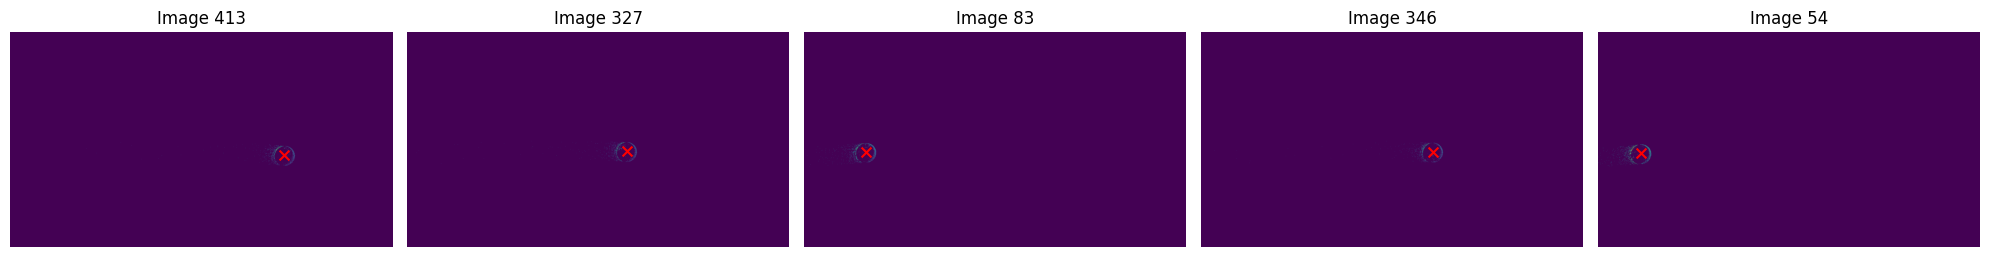

In [174]:
import random

random_indices = random.sample(range(images.shape[0]), 5)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, idx in zip(axes, random_indices):
    ax.imshow(images[idx]*255 / np.max(images[idx]))
    c = find_coord(idx)
    print(c)
    ax.scatter(c[0], c[1], color='red', s=50, marker='x')
    ax.set_title(f'Image {idx}')
    ax.axis('off')
plt.tight_layout()
plt.show()

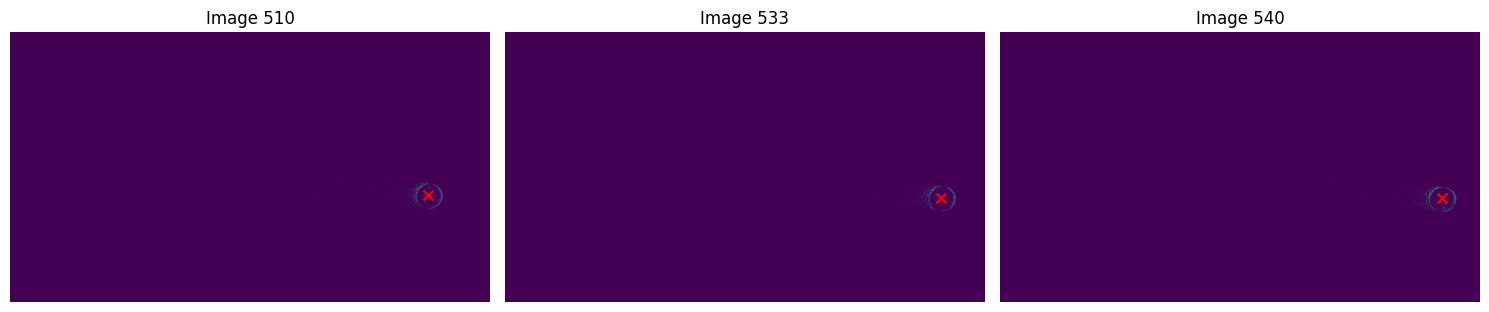

In [178]:
indices = [510, 533, 540]
fig, axes = plt.subplots(1, len(indices), figsize=(15, 4))
for ax, idx in zip(axes, indices):
    ax.imshow(images[idx]*255 / np.max(images[idx]))
    c = find_coord(idx)
    ax.scatter(c[0], c[1], color='red', s=50, marker='x')
    ax.set_title(f'Image {idx}')
    ax.axis('off')
plt.tight_layout()
plt.show()